In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [155]:
df = pd.read_csv(r'C:\Users\DELL\Desktop\Data\datasets\raws\pharmacy_otc_sales_data.csv')
df.Date = pd.to_datetime(df.Date)

In [156]:
df.sample(10)

,Date,Product,Sales Person,Boxes Shipped,Amount ($),Country
65,2022-07-16,Nasal Spray,Ritika Shah,9,158.69,India
158,2022-06-11,Allergy Pills,Sneha Iyer,2,46.75,Australia
11,2022-02-18,Pain Relief Tablets,Ritika Shah,5,63.41,USA
68,2022-08-05,Allergy Pills,Nikhil Batra,10,245.90,USA
294,2022-06-03,Cough Syrup,Priya Singh,19,341.45,UK
247,2022-08-03,Eye Drops,Aman Verma,6,88.20,India
130,2022-06-27,Allergy Pills,Rajesh Patel,15,176.45,USA
207,2022-07-09,Allergy Pills,Aman Verma,20,176.04,UK
231,2022-07-13,Digestive Enzyme,Rajesh Patel,18,431.39,India
167,2022-02-11,Pain Relief Tablets,Rajesh Patel,15,268.43,Canada


In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           333 non-null    datetime64[us]
 1   Product        333 non-null    str           
 2   Sales Person   333 non-null    str           
 3   Boxes Shipped  333 non-null    int64         
 4   Amount ($)     333 non-null    float64       
 5   Country        333 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 15.7 KB


In [158]:
df.duplicated().any()

np.False_

Data types looks good. No duplicated values and no NaN values.

Total Amount ($) and Boxes Shipped by Country:

In [159]:
df.groupby('Country').agg({'Boxes Shipped':'sum','Amount ($)':'sum'})

,Boxes Shipped,Amount ($)
Country,,
Australia,587,9698.37
Canada,689,11967.08
India,665,11122.06
UK,752,12032.30
USA,795,14109.48


Total of Boxes Shipped and earnings by the Sales team

In [160]:
df.groupby('Sales Person').agg({'Boxes Shipped':'sum','Amount ($)':'sum'}).sort_values('Boxes Shipped',ascending=False)

,Boxes Shipped,Amount ($)
Sales Person,,
Rajesh Patel,614,11023.53
Nikhil Batra,565,10416.34
Priya Singh,558,9121.78
Aman Verma,466,7039.07
Divya Mehra,455,6896.15
Ritika Shah,449,7945.97
Sneha Iyer,381,6486.45


Total Boxes Shipped and earnings by Product.

In [161]:
df.groupby('Product').agg({'Boxes Shipped':'sum','Amount ($)':'sum'}).sort_values('Boxes Shipped',ascending=False)

,Boxes Shipped,Amount ($)
Product,,
Digestive Enzyme,612,11056.61
Antiseptic Cream,573,9736.28
Allergy Pills,518,7782.58
Nasal Spray,489,8407.36
Cough Syrup,484,7917.01
Eye Drops,458,8036.36
Pain Relief Tablets,354,5993.09


Total Boxes Shipped and earnigns by Country and Sales Person

In [162]:
df.groupby(['Country','Sales Person']).agg({'Boxes Shipped':'sum','Amount ($)':'sum'})

Boxes Shipped  Amount ($)
Country   Sales Person                           
Australia Aman Verma               69     1083.31
          Divya Mehra              65      797.43
          Nikhil Batra             56     1090.46
          Priya Singh              92     1626.75
          Rajesh Patel            154     2824.40
          Ritika Shah              94     1460.45
          Sneha Iyer               57      815.57
Canada    Aman Verma               64      882.72
          Divya Mehra             147     2253.26
          Nikhil Batra             95     1910.37
          Priya Singh             106     1672.62
          Rajesh Patel            120     2186.38
          Ritika Shah             101     2073.19
          Sneha Iyer               56      988.54
India     Aman Verma               81     1277.08
          Divya Mehra              62     1044.75
          Nikhil Batra            133     2388.72
          Priya Singh              94     1468.83
          Rajesh Patel            117     1917.91
          Ritika Shah             118     2168.91
          Sneha Iyer               60      855.86
UK        Aman Verma              103     1230.33
          Divya Mehra              89     1433.88
          Nikhil Batra            100     1756.04
          Priya Singh             161     2654.99
          Rajesh Patel            117     1986.36
          Ritika Shah              65      840.49
          Sneha Iyer              117     2130.21
USA       Aman Verma              149     2565.63
          Divya Mehra              92     1366.83
          Nikhil Batra            181     3270.75
          Priya Singh             105     1698.59
          Rajesh Patel            106     2108.48
          Ritika Shah              71     1402.93
          Sneha Iyer               91     1696.27

Heatmap: Total earned by Country and Sales Person

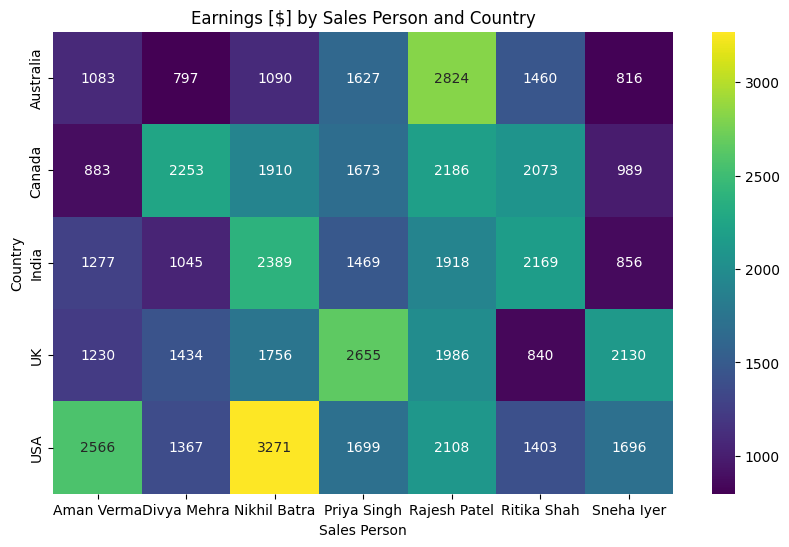

In [163]:
df_grouped = (
    df.groupby(['Country', 'Sales Person'])
    .agg({'Boxes Shipped':'sum','Amount ($)':'sum'}).reset_index()
)

pivot = df_grouped.pivot(
    index='Country',
    columns='Sales Person',
    values='Amount ($)'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='viridis', fmt='.0f')
plt.title('Earnings [$] by Sales Person and Country')
plt.show()

Analyzing time dimension for the most shipped product: Antiseptic Cream

In [164]:
df.value_counts('Date')

Date
2022-05-23    6
2022-04-27    5
2022-06-03    5
2022-01-07    5
2022-02-08    5
             ..
2022-03-09    1
2022-04-25    1
2022-08-29    1
2022-04-12    1
2022-01-05    1
Name: count, Length: 179, dtype: int64

One to many relationship between Date and table entries

In [165]:
de_df = df.loc[df.Product=='Digestive Enzyme'].groupby('Date',as_index='Date').agg({'Boxes Shipped':'sum'}).sort_index()

In [166]:
de_df.head(5)

,Boxes Shipped
Date,
2022-01-02,14
2022-01-07,11
2022-01-13,15
2022-01-17,8
2022-01-19,29


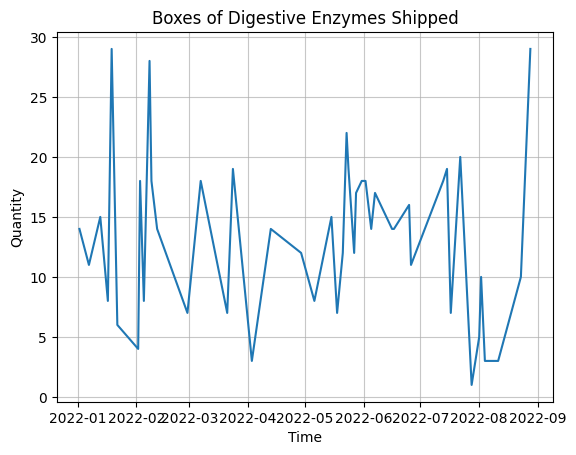

In [167]:
plt.plot(de_df.index,de_df['Boxes Shipped'])
plt.title('Boxes of Digestive Enzymes Shipped')
plt.xlabel('Time')
plt.ylabel('Quantity')
plt.grid('.',alpha=.7,)

Softening Digestive Enzymes Sales Time Series with a 7-day rolling mean

In [168]:
de_weekly = de_df.rolling(window=7).mean()

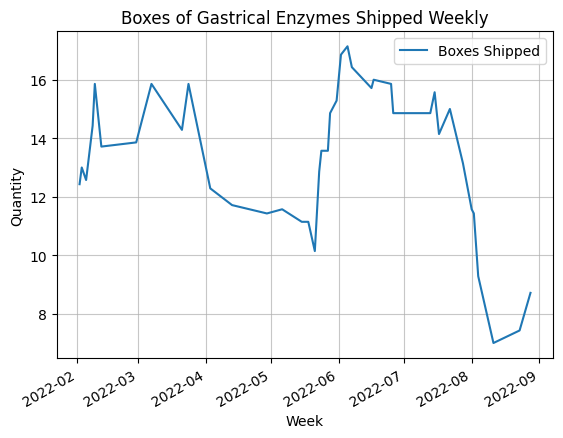

In [169]:
de_weekly.plot()
plt.title('Boxes of Gastrical Enzymes Shipped Weekly')
plt.xlabel('Week')
plt.ylabel('Quantity')
plt.grid(alpha=.7)

**Exploring the other time series (daily, hourly)**

Glossary:

*M01AB - Anti-inflammatory and antirheumatic products, non-steroids, Acetic acid derivatives and related substances \
M01AE - Anti-inflammatory and antirheumatic products, non-steroids, Propionic acid derivatives \
N02BA - Other analgesics and antipyretics, Salicylic acid and derivatives \
N02BE/B - Other analgesics and antipyretics, Pyrazolones and Anilides \
N05B - Psycholeptics drugs, Anxiolytic drugs \
N05C - Psycholeptics drugs, Hypnotics and sedatives drugs \
R03 - Drugs for obstructive airway diseases \
R06 - Antihistamines for systemic use Sales data are resampled to the hourly, daily, weekly and monthly periods. Data is already pre-processed, where processing included outlier detection and treatment and missing data imputation.*

In [170]:
daily_df = pd.read_csv(r'C:\Users\DELL\Desktop\Data\datasets\raws\pharma_sales_Data\salesdaily.csv')
daily_df.datum = pd.to_datetime(daily_df.datum)
daily_df.duplicated().any()

np.False_

In [171]:
#daily_df.info()

In [172]:
daily_df.head(1)

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.4,7.0,0.0,0.0,2.0,2014,1,248,Thursday


Year, Month and Hour columns doesn't make any sense. I'll drop them.

In [173]:
daily_df = daily_df.drop(columns=['Year','Month','Hour'])

I'm going to group sales by day of the week. I'm seeking for a pattern.

In [174]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday']

result = (
    daily_df
    .groupby('Weekday Name')
    .sum(numeric_only=True)
    .reindex(weekday_order)
)


result.style.background_gradient(cmap='coolwarm')

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Weekday Name,,,,,,,,
Monday,1521.776667,1118.503000,1171.765667,8799.013000,2783.316667,185.458333,1791.458333,871.525000
Tuesday,1519.246667,1069.307583,1272.966667,8540.473167,2896.766667,219.166667,1629.197917,918.121667
Wednesday,1439.206667,1110.250000,1131.431667,8422.354167,3037.183333,196.250000,1635.000000,799.851667
Thursday,1369.300000,1092.282396,1110.037500,8478.629375,2623.429167,154.125000,1595.625000,788.960833
Friday,1435.913333,1117.781083,1167.448333,8606.187167,2979.233333,229.500000,1756.041667,842.386667
Saturday,1724.054167,1311.554917,1262.671667,10107.495333,2580.941667,164.750000,1629.666667,986.460000
Sunday,1591.439583,1384.939667,1055.887500,10051.250500,1744.866667,100.708333,1571.833333,900.511667


It seems some products have the tendency of being more sold on weekends (M01AB,N02BE,M01AE).

Text(0, 0.5, 'Quantity')

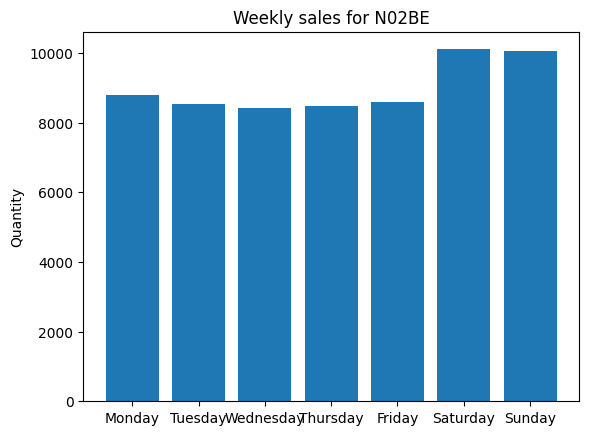

In [175]:
plt.bar(result.index,height=result.loc[:,'N02BE'])
plt.title('Weekly sales for N02BE')
plt.ylabel('Quantity')

Are sales for N02BE independent from the week day?

In [176]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(result)

print(f'chi2 = {chi2:.3f}')
print(f'p-value = {p:.5f}')

chi2 = 885.064
p-value = 0.00000


No. It's significative.

The following table shows (when values are above 2) when it's bought more than expected. This mirrors the 'result' table.

In [177]:
observed = result.values  
residuals = (observed - expected) / np.sqrt(expected)

res_df = pd.DataFrame(residuals,index=result.index,columns=result.columns)

res_df.style.background_gradient(cmap='coolwarm')

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Weekday Name,,,,,,,,
Monday,0.157204,-1.592498,0.098114,-2.203220,2.275034,0.504703,3.232699,-0.058645
Tuesday,0.473474,-2.708710,3.408106,-4.023034,4.999278,3.171813,-0.355299,1.814673
Wednesday,-0.970559,-0.961144,-0.201415,-3.768807,8.638072,1.679152,0.450649,-1.743301
Thursday,-1.606363,-0.435998,0.229564,-0.224303,2.156519,-1.116034,0.748418,-1.218359
Friday,-1.822543,-1.414408,0.175302,-3.682237,6.395127,3.890136,2.613051,-0.871802
Saturday,2.016384,1.134940,-0.095524,3.506670,-5.725577,-2.076669,-3.980745,1.307268
Sunday,1.601126,5.863494,-3.573626,10.121413,-18.207486,-5.925456,-2.501560,0.662442


To continue: EDA \
Next: ARIMA/SARIMA

In [178]:
hourly_df = pd.read_csv(r'C:\Users\DELL\Desktop\Data\datasets\raws\pharma_sales_Data\saleshourly.csv')
hourly_df.datum = pd.to_datetime(hourly_df.datum)

In [179]:
print(hourly_df.duplicated().any())
hourly_df.info()

False
<class 'pandas.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         50532 non-null  datetime64[us]
 1   M01AB         50532 non-null  float64       
 2   M01AE         50532 non-null  float64       
 3   N02BA         50532 non-null  float64       
 4   N02BE         50532 non-null  float64       
 5   N05B          50532 non-null  float64       
 6   N05C          50532 non-null  float64       
 7   R03           50532 non-null  float64       
 8   R06           50532 non-null  float64       
 9   Year          50532 non-null  int64         
 10  Month         50532 non-null  int64         
 11  Hour          50532 non-null  int64         
 12  Weekday Name  50532 non-null  str           
dtypes: datetime64[us](1), float64(8), int64(3), str(1)
memory usage: 5.0 MB


In [180]:
hourly_df_grouped = (
    hourly_df.drop(columns=['Year','Month'])
    .groupby('Hour')
    .sum(numeric_only=True)
)

In [181]:
hourly_df_grouped.style.background_gradient('coolwarm')

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Hour,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,28.180000,38.363000,25.000000,338.724500,62.000000,4.000000,59.000000,17.300000
8,561.249167,325.197500,432.766667,2707.827500,1029.791667,49.000000,659.416667,275.500000


Total Sales by Hour

In [182]:
hourly_df_total = hourly_df_grouped.sum(axis=1)

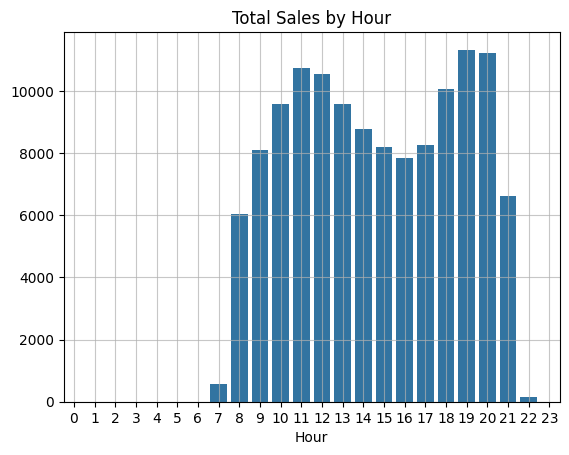

In [183]:
sns.barplot(hourly_df_total).set_title('Total Sales by Hour')
plt.grid(alpha=.7)

I'm going to try to map Product to Product Code (M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06)

In [184]:
df.Product.unique()

<StringArray>
['Pain Relief Tablets',    'Antiseptic Cream',         'Cough Syrup',
    'Digestive Enzyme',           'Eye Drops',         'Nasal Spray',
       'Allergy Pills']
Length: 7, dtype: str

Since there're products that don't have any related code, I'm inventing the missing ones so I can extend the analysis.

In [185]:
mapping = {
    'Pain Relief Tablets': 'N02PX',   # aggregate analgesics / NSAIDs
    'Antiseptic Cream': 'D08AX',      # antiseptics & disinfectants
    'Cough Syrup': 'R05CX',           # cough & cold preparations
    'Digestive Enzyme': 'A09AX',      # digestive enzymes
    'Eye Drops': 'S01XA',             # ophthalmological preparations
    'Nasal Spray': 'R01AX',           # nasal preparations
    'Allergy Pills': 'R06'
}

In [186]:
df['Product Code'] = df.Product.map(mapping)

In [187]:
df.Date.dt.year.min()

np.int32(2022)

In [188]:
hourly_df.loc[hourly_df.datum.dt.year==2022]

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name


I cannot merge hourly nor weekly data with sales data :( . They don't match in time. Could've been great if I could match with  Country data

In [189]:
monthly_df = pd.read_csv(r'C:\Users\DELL\Desktop\Data\datasets\raws\pharma_sales_Data\salesmonthly.csv')
monthly_df.datum = pd.to_datetime(monthly_df.datum)

In [190]:
daily_df['Weekday Name'].unique()

<StringArray>
['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 7, dtype: str

In [191]:
weekday_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

In [192]:
df.Date.dt.weekday.isna().any()

np.False_

In [193]:
df['Weekday'] = df.Date.dt.weekday.map(weekday_map)

In [194]:
df['Weekday']

0         Sunday
1       Saturday
2       Saturday
3         Monday
4         Monday
         ...    
328      Tuesday
329       Sunday
330       Sunday
331    Wednesday
332     Thursday
Name: Weekday, Length: 333, dtype: str

I want to know on wich country the sales are maximum on each week day

In [ ]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

df['Weekday'] = pd.Categorical(df['Weekday'], categories=weekday_order, ordered=True)

result = (
    df.groupby(['Weekday', 'Country'])['Amount ($)']
    .sum()
    .sort_index()
    .idxmax()
)


sales = df.groupby(['Weekday', 'Country'])['Amount ($)'].sum()

result = sales.loc[
    sales.groupby(level=0).idxmax()
]

result

Weekday    Country
Monday     USA        2340.67
Tuesday    Canada     2159.38
Wednesday  India      2390.93
Thursday   Canada     1952.41
Friday     USA        3216.72
Saturday   USA        2593.65
Sunday     UK         2513.32
Name: Amount ($), dtype: float64
